In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
df = pd.read_excel("../data/online_retail_II.xlsx")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
# Shape of the dataset
df.shape


(525461, 8)

In [5]:
# Column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

df.describe()

Missing values per column:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

Duplicate rows: 6865


,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [41]:
df["Country"].unique()

array(['United Kingdom', 'France', 'USA', 'Belgium', 'Australia', 'EIRE',
       'Germany', 'Portugal', 'Japan', 'Denmark', 'Nigeria',
       'Netherlands', 'Poland', 'Spain', 'Channel Islands', 'Italy',
       'Cyprus', 'Greece', 'Norway', 'Austria', 'Sweden',
       'United Arab Emirates', 'Finland', 'Switzerland', 'Unspecified',
       'Malta', 'Bahrain', 'RSA', 'Bermuda', 'Hong Kong', 'Singapore',
       'Thailand', 'Israel', 'Lithuania', 'West Indies', 'Lebanon',
       'Korea', 'Brazil', 'Canada', 'Iceland'], dtype=object)

In [42]:
df["Customer ID"].nunique()

4383

In [44]:
df["Description"].nunique()

4681

In [8]:
df_clean = df.dropna(subset=["Customer ID"]).copy()

df_clean = df_clean.drop_duplicates()

df_clean = df_clean[~df_clean["Invoice"].astype(str).str.startswith("C")]

df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["Price"] > 0)]

df_clean["Customer ID"] = df_clean["Customer ID"].astype(int)

print(f"Original rows: {df.shape[0]}")
print(f"Cleaned rows:  {df_clean.shape[0]}")
print(f"Dropped {df.shape[0] - df_clean.shape[0]} invalid / cancelled / guest records.")

Original rows: 525461
Cleaned rows:  400916
Dropped 124545 invalid / cancelled / guest records.


In [9]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
df_clean["Month"] = df_clean["InvoiceDate"].dt.to_period("M")
df_clean["Sales"] = df_clean["Quantity"] * df_clean["Price"]

print(f"Total Clean Revenue: ${df_clean['Sales'].sum():,.2f}")
print(f"Total Unique Customers: {df_clean['Customer ID'].nunique():,}")
print(f"Total Unique Products:  {df_clean['Description'].nunique():,}")

Total Clean Revenue: $8,798,233.74
Total Unique Customers: 4,312
Total Unique Products:  4,444


# top 10 country

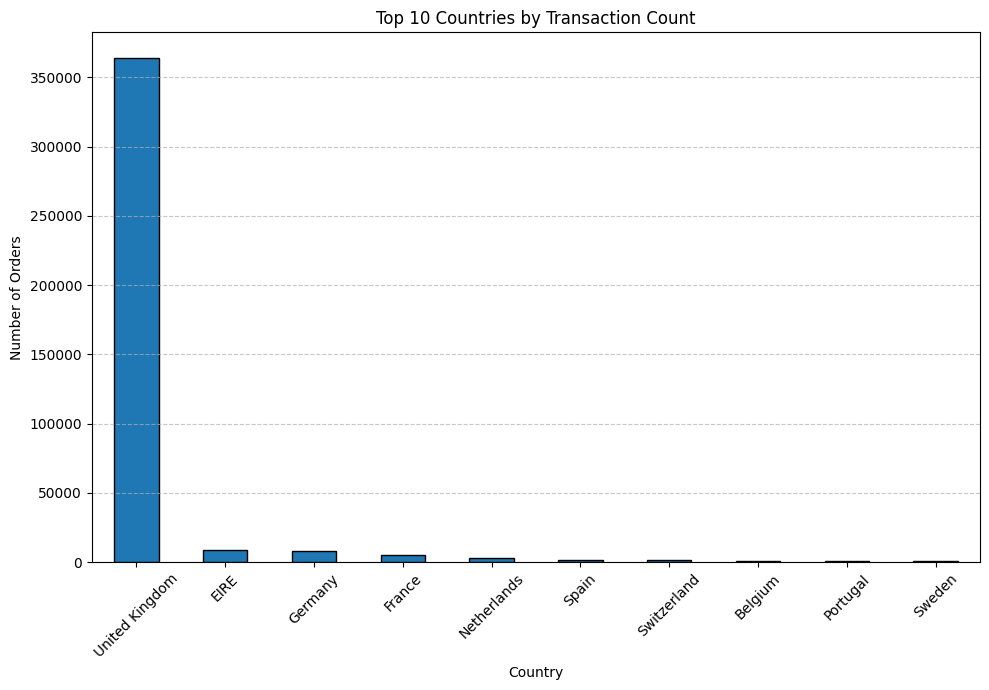

In [21]:
top_country = df_clean["Country"].value_counts().head(10)

plt.figure(figsize=(10, 7))
top_country.plot(kind="bar", edgecolor="black")
plt.title("Top 10 Countries by Transaction Count")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# top 10 selling products

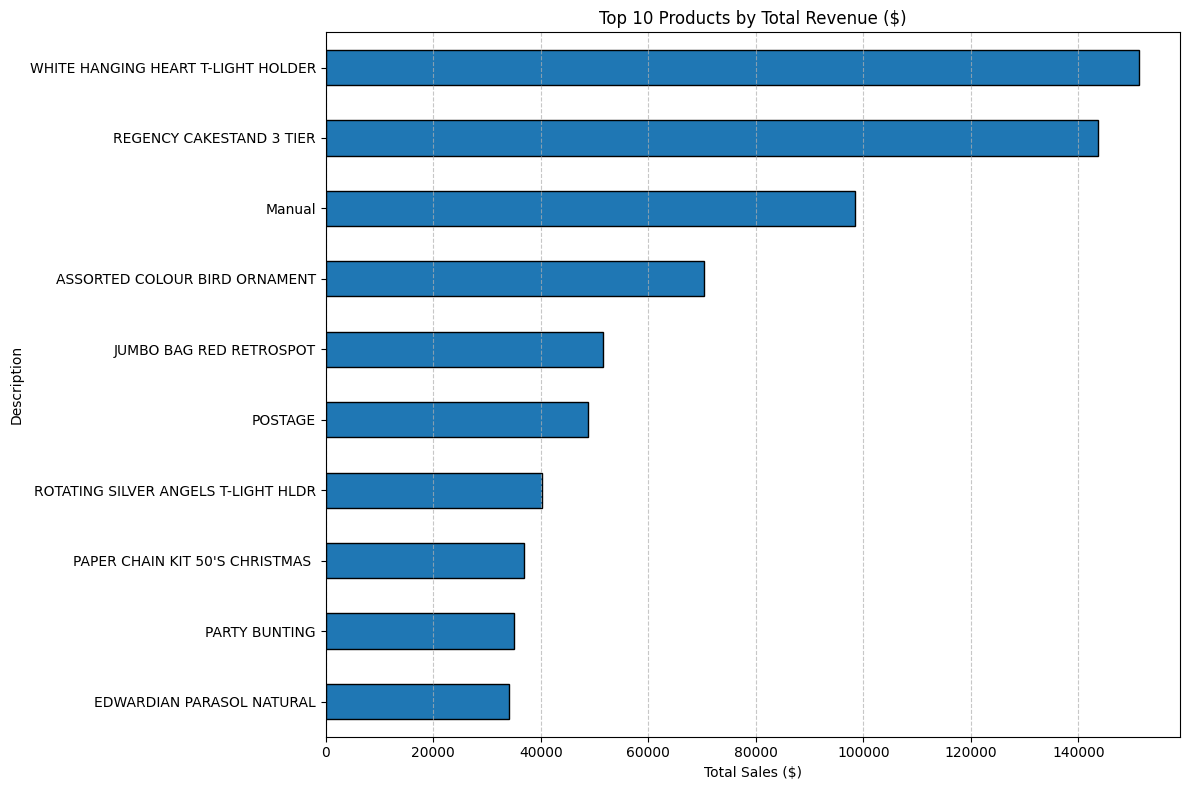

In [20]:
top_products_rev = df_clean.groupby("Description")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
top_products_rev.plot(kind="barh", edgecolor="black")
plt.title("Top 10 Products by Total Revenue ($)")
plt.xlabel("Total Sales ($)")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [16]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [17]:
df["Sales"] = df["Quantity"] * df["Price"]

# monthly sales

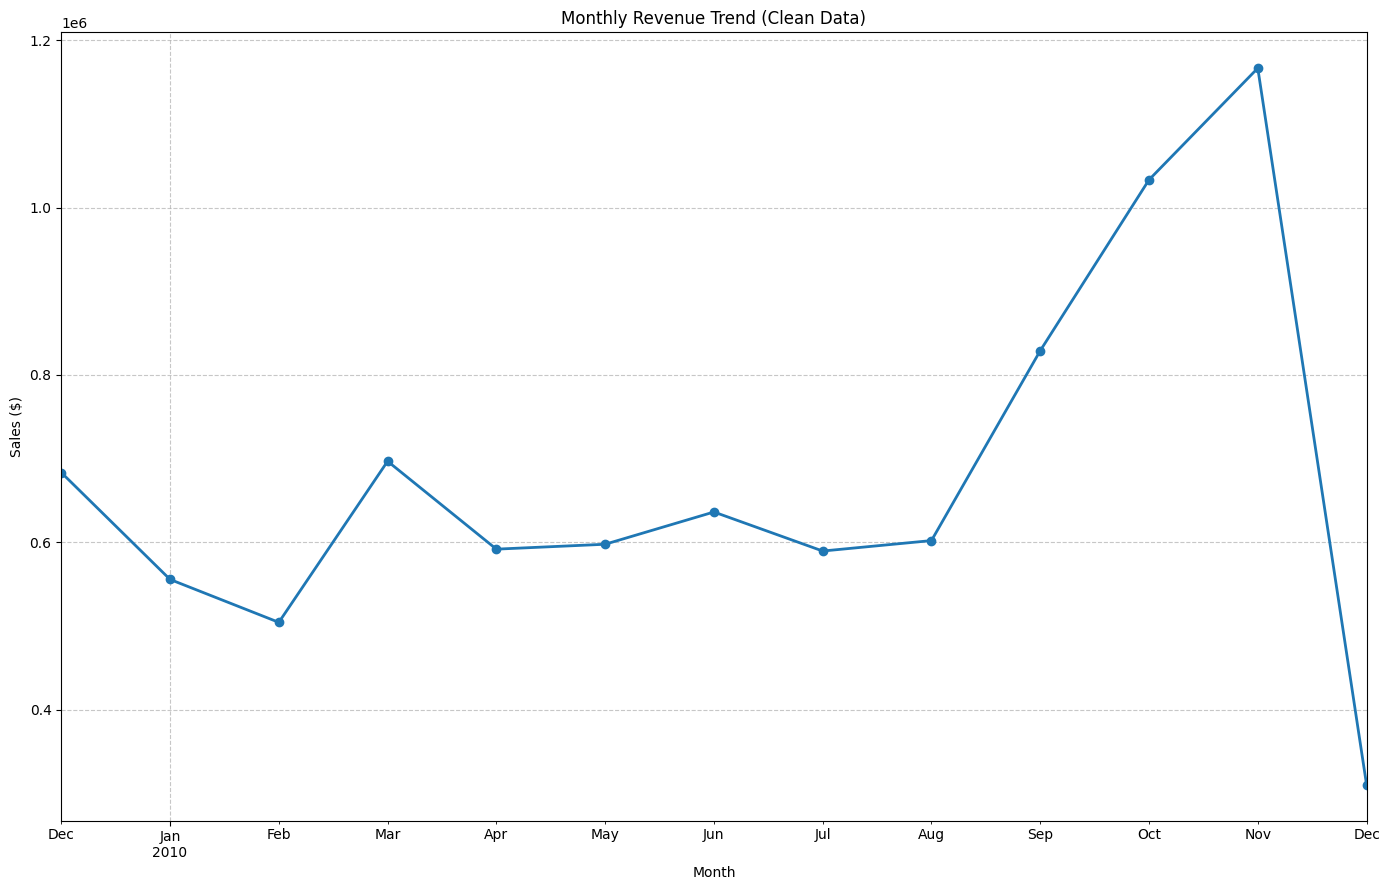

In [26]:
monthly_sales = df_clean.groupby("Month")["Sales"].sum()

plt.figure(figsize=(14, 9))
monthly_sales.plot(kind="line", marker="o", linewidth=2)
plt.title("Monthly Revenue Trend (Clean Data)")
plt.ylabel("Sales ($)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [28]:
df_clean.to_csv("../data/online_retail_clean.csv", index=False)
print("Successfully exported clean data to data/online_retail_clean.csv")

Successfully exported clean data to data/online_retail_clean.csv


In [29]:
# ==============================================================================
# TIME-SERIES FORECAST EVALUATION (MAE, RMSE, MAPE, R2)
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_clean = pd.read_csv("../data/online_retail_clean.csv")
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
monthly = df_clean.set_index("InvoiceDate").resample("MS")["Sales"].sum().reset_index()

# Split: Train on earlier months, Test on the last 3 months
train = monthly.iloc[:-3]
test = monthly.iloc[-3:]

# Fit Linear Trend Model
x_train = np.arange(len(train))
slope, intercept = np.polyfit(x_train, train["Sales"].values, 1)

# Predict Test Period
x_test = np.arange(len(train), len(monthly))
y_pred = slope * x_test + intercept
y_true = test["Sales"].values

# Calculate Metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print("--- Sales Forecasting Performance Metrics ---")
print(f"MAE (Mean Absolute Error):       ${mae:,.2f}")
print(f"RMSE (Root Mean Squared Error):  ${rmse:,.2f}")
print(f"MAPE (Mean Absolute % Error):    {mape:.2f}%")
print(f"R² Score:                        {r2:.4f}")

--- Sales Forecasting Performance Metrics ---
MAE (Mean Absolute Error):       $402,906.94
RMSE (Root Mean Squared Error):  $405,970.57
MAPE (Mean Absolute % Error):    67.59%
R² Score:                        -0.1660


In [30]:
# ==============================================================================
# ROUGE SCORE EVALUATION (NLP / PRODUCT DESCRIPTION MATCHING)
# ==============================================================================
def calculate_rouge_n(candidate: str, reference: str, n: int = 1):
    """
    Computes ROUGE-N Precision, Recall, and F1-Score based on n-gram token overlap.
    """
    cand_tokens = candidate.lower().strip().split()
    ref_tokens = reference.lower().strip().split()

    def get_ngrams(tokens, n_val):
        return [tuple(tokens[i:i + n_val]) for i in range(len(tokens) - n_val + 1)]

    cand_ngrams = get_ngrams(cand_tokens, n)
    ref_ngrams = get_ngrams(ref_tokens, n)

    if not cand_ngrams or not ref_ngrams:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0}

    cand_set = set(cand_ngrams)
    ref_set = set(ref_ngrams)
    overlap = len(cand_set.intersection(ref_set))

    precision = overlap / len(cand_set) if cand_set else 0.0
    recall = overlap / len(ref_set) if ref_set else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4)
    }

# Example Evaluation on Product Descriptions:
generated_desc = "strawberry ceramic trinket box jewelry storage handcrafted gift"
reference_desc = "strawberry ceramic trinket box handcrafted gift container"

rouge_1 = calculate_rouge_n(generated_desc, reference_desc, n=1)
rouge_2 = calculate_rouge_n(generated_desc, reference_desc, n=2)

print("--- ROUGE Score Evaluation ---")
print(f"ROUGE-1 (Unigram Overlap): Precision={rouge_1['precision']}, Recall={rouge_1['recall']}, F1={rouge_1['f1']}")
print(f"ROUGE-2 (Bigram Overlap):  Precision={rouge_2['precision']}, Recall={rouge_2['recall']}, F1={rouge_2['f1']}")

--- ROUGE Score Evaluation ---
ROUGE-1 (Unigram Overlap): Precision=0.75, Recall=0.8571, F1=0.8
ROUGE-2 (Bigram Overlap):  Precision=0.5714, Recall=0.6667, F1=0.6154
